---
title: Neuro Signal Processing - Filtering and data manipulation
short_title: Filtering  
subtitle: Using signal processing tools to analyze neural data
description: In this quest we will use simulated data to practice working with arrays.

---


# Neuro Signal Quest 1

This chapter will help you get develop your numpy array skills in Python. To solve the following exercises you need to have some basic understanding of:

- arrays and indexing
- loops and if statements
- basic plotting (you might also learn as you go)

## Simulating and plotting signals 

The code below uses numpy arrays to simulate an oscillatory signal, similar to an EEG or LFP signal. It first start by creating an array `time` with time stamps. Those are the times in which the simulated electrode sampled the voltage activity of the brain. Because most recording systems have a fixed sampling time, we can just create an array `time` with equally spaced times, denoted by the variable `dt` (referring to $\Delta t$, the difference between two consecutive time samples $t_i$ and $t_{i+1}$). In this case, `time` starts at time 0 and stops at time 100 (we will assume that time and dt are in seconds).


:::{note} EEG and LFP signals
:class: dropdown
In neuroscience there are multiple ways to measure the activity of the brain. One of the most common ones is by using voltage as an indicator of neuronal activity (neurons change their internal voltage whenever they fire an action potential). In humans, it's common to put an electrode in contact with the head skin to measure the voltage changes occurring within the brain. That signal, the electroencefalogram signal (or simply EEG), is usually quite noisy, and it's hard to find its exact source, since the electrode is so far from a particular source. However, since we are very good in measuring voltage, it has a good temporal resolution. 

Whenever it is possible to place an electrode inside the brain (e.g., if you are already going to do an invasive procedure anyways or if you are working with animal models) it's possible to get a sligthly more accurate signal. From that signal, one can look both into the activity of individual neurons very close to the tip of the electrode - known as spiking activity - as into the general activity of neurons in the region - known as the local field potential (LFP). The later one, is very similar to the EEG signal, except that in this case you can more easily pinpoint where the signal comes from based on the coordinates of the implant. 

A good analogy to understand these electrode recordings and the type of signal they convey is to think of someone calling you from a party. Maybe you can hear what your friend and a few other people that are very close to the phone are talking. That is the spiking activity. But you can also hear the general chattering in the background (without recognizing any word, but knowing it comes from a particular room). That's the local field potential. At last, it may be that the only thing you can hear is a bit of the chatter covered by the loud music playing, which can be heard from everywhere in the party. That is the EEG signal.

In this analogy, every person in the party is a neuron, your phone is an electrode inside the brain or in the scalp, and the music playing is what we call "noise", a signal that is does not carry any information about the neurons. Of course this analogy is not perfect, but it helps conveying the idea of what those signals are. 

:::

:::{code-cell} python
:linenos:
:emphasize-lines: 4-5
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
time = np.arange(0,100,dt)
:::

Note that the $\Delta t$ can also be defined in terms of the sampling rate (`srate`) of the recording system simulated here by the following equation:

$\Delta t = 1/srate$

After that, we can use our `time` array to create two pure oscillations: one in 8 Hz and another in 25 Hertz. This can be done by using a cosine (or sine) function with an angle that varies over time

$s(t) = cos(\theta(t))$

The rate in which $\theta$ changes defines the frequency of our oscillation. Because the cosine function receives a frequency in radians ($\omega$), if we want to define our oscillation using a frequency in Hertz ($f$) we need to use the following equivalence:

$\omega= 2\pi f$

Hence, our oscillation becomes

$s(t) = cos(2\pi f(t))$

Well, the last step is just to consider the function $f(t) = f_{const} t$, in which $f_{const}$ a constant frequency denoted by the variables `f1` and `f2`, and $t$ is the time, denoted by the variable `time`.


:::{code-cell} python
:linenos:
:emphasize-lines: 7-10
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
time = np.arange(0,100,dt)

f1 = 8
f2 = 25
sig1 = 0.5*np.cos(time*2*np.pi*8)
sig2 = 0.2*np.cos(time*2*np.pi*25)
:::

Note that each signal is multiplied entirely by a scalar (0.5 or 0.1). This is just to scale each signal to a different size. In real life, the size of signals depend on factors like the resistance of the electrode, the amplification of the recording system and so on. But there is a natural tendency of faster frequencies to have less amplitude in biological systems.   

At last, we simulate some noise by creating a random array of the same size of our signal and adding it to it before ploting.

:::{code-cell} python
:linenos:
:emphasize-lines: 12-13
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
time = np.arange(0,100,dt)

f1 = 8
f2 = 25
sig1 = 0.5*np.cos(time*2*np.pi*8)
sig2 = 0.2*np.cos(time*2*np.pi*25)

noise = 0.1*np.random.randn(time.shape[0])
signal = sig1+sig2+noise
:::

We can now plot each individual oscillation, the noise, and the sum of all of them, comprising our simulated signal.

:::{code-cell} python
:tags: [skip-execution]
:linenos:
:emphasize-lines: 12-13

plt.plot(time, noise,'m')
plt.plot(time, sig1,'r')
plt.plot(time, sig2,'b')
plt.plot(time, signal,'k')
plt.xlim((0,1))
plt.legend(['noise','sig1', 'sig2', 'signal'])
plt.show()

:::

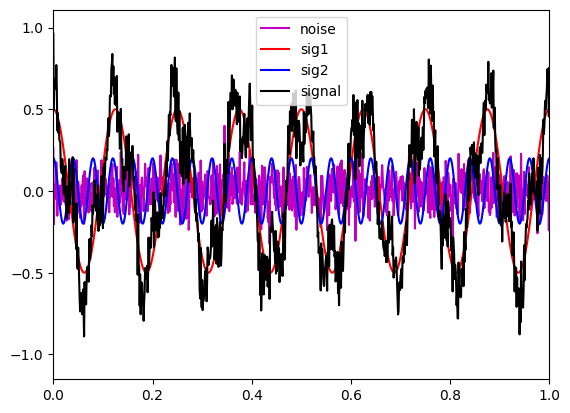

In [57]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
time = np.arange(0,100,dt)

f1 = 8
f2 = 25
sig1 = 0.5*np.cos(time*2*np.pi*8)
sig2 = 0.2*np.cos(time*2*np.pi*25)

noise = 0.1*np.random.randn(time.shape[0])
signal = sig1+sig2+noise

plt.plot(time, noise,'m')
plt.plot(time, sig1,'r')
plt.plot(time, sig2,'b')
plt.plot(time, signal,'k')
plt.xlim((0,1))
plt.legend(['noise','sig1', 'sig2', 'signal'])
plt.show()


That is a very simple example of a simulated signal. Now imagine that the oscillations depicted above in black is the signal that arrives from one of your EEG or LFP recordings. You can clearly see that there are oscillations happening there (the 8 Hz is quite visible!), but it's hard to disentangle anything else. What can we do then, to understand what's going on in this signal?

One possibility is to filter the signal. Filtering is a procedure that allow us to remove or isolate certain frequencies in our signal. You can understand a bit more about filtering by studying [convolution](wiki:Convolution) and the [Fourier transform](wiki:Fourier_transform), but for now, let's use the following function below to filter our data.  

In [30]:
import scipy.signal as sig
def filter(signal, f_low, f_high, srate):
    b, a = sig.butter(
        N=4,
        Wn=(f_low, f_high),
        btype="bandpass",
        fs=srate,
    )
      
    filtered = sig.filtfilt(b, a, signal)

    return filtered


The function will receive a signal (`signal`), a lower bound frequency `f_low` and an upper bound frequency `f_high`, and the sampling rate (`srate`), and return a filtered signal containing only the frequencies between `f_low` and `f_high`.


### Exercise 1:

Use the filter function above to filter two components present in `signal`: one from 5 to 10 Hz, and another from 20 to 40.

Plot the two components in a new plot. Also plot the difference between the original `sig1` and `sig2` with their respective filtered components.

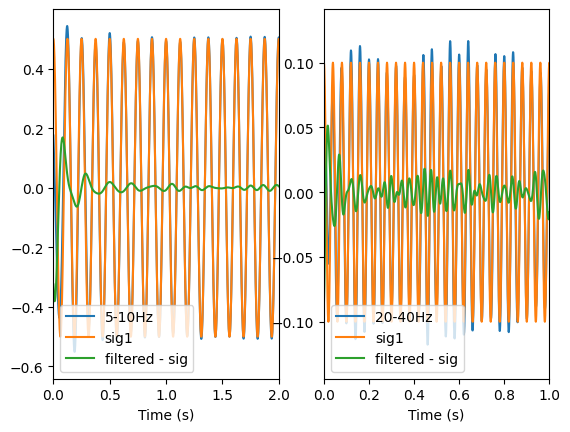

In [ ]:
# Your code goes here.



::::{dropdown} Solution
:::{code-cell} python
filt1 = filter(signal, 5,10, 1/dt)
filt2 = filter(signal, 20,40, 1/dt)

plt.subplot(1,2,1)
plt.plot(time, filt1)
plt.plot(time, sig1)
plt.plot(time, filt1-sig1)
plt.xlim(0,2)
plt.xlabel('Time (s)')
plt.title('Filtering the 8 Hz component')
plt.legend(['5-10Hz', 'sig1', 'filtered - sig1'])

plt.subplot(1,2,2)
plt.plot(time, filt2)
plt.plot(time, sig2)
plt.plot(time, filt2-sig2)
plt.xlim(0,1)
plt.xlabel('Time (s)')
plt.legend(['20-40Hz', 'sig2', 'filtered - sig2'])
plt.title('Filtering the 25 Hz component')
plt.show()
:::

:::{note} Noise and Edge effects
Note that the filtered signals and the original components are not exactly the same. This is because the noise added might also have some frequency on the filtered band. 

In addition to that, you can notice that in the beginning of the filtered signal (and in the end) the difference is bigger. This is because of some edge effects of filtering. The filter uses a window of the signal (defined by the order of the filter) to estimate how much each frequency is present in the signal. However, this window is ill-defined at the edges of the signal.

Notice that each frequency band needs a window of different size to estimate how much that frequency is present in the signal. Because of that, the edge effects last longer when filtering lower frequencies (since the wavelength of one cycle of that frequency lasts longer) than higher frequencies.  
:::
::::

### Exercise 2:

Use the functions `np.mean()` and `np.std()` to calculate the average (μ) of and standard deviation (σ) of the synthetic signal generated (signal). Use that to define a threshold of $\mu + 1.5*\sigma$

Plot the signal (in black) and the threshold (as a dashed line). In addition to that, replot all the signal traces that are above the threshold (as disconected dots in red)

Limit your plot to the first 1 second.



In [67]:
# Your code goes here.




::::{dropdown} Solution

:::{code-cell} python

m = np.mean(signal)
s = np.std(signal)

threshold = m+1.5*s

plt.plot(time, signal,'k')
plt.plot([time[0],time[-1]], [threshold,threshold], 'k--')
plt.plot(time[signal>threshold], signal[signal>threshold], 'r.')
plt.xlim(0,1)
plt.show()
:::
::::


## Part 2

The functions `np.where` can be very useful to find indices of an array that fulfill certain conditions. For example, look at the code below:
```{code-cell} python
import numpy as np

arr = np.array([1,2,3,5,5,7,10])
indices = np.where(arr==5)
```
The variable `indices` is the tuple `(array([3, 4]), )` in which the first element is an array with the indices of `arr` in which the condition `arr==5` is True.

This means we can use indices to access all the elements of arr that fulfill the condition:

```{code-cell} python

print(arr[indices[0]])
```

One might ask, how is this different than `arr[arr==5]`? It is true that they result in the same operation. However, sometimes one needs to do operations in the indices themselves. For example, imagine that you have a signal and want to get periods in which the signal is higher than a threshold for 3 consecutive points.

You could do something like `signal[signal>threshold]` to get the values above the threshold, but that does not guarantee that you will have consecutive activation. Instead, if you use np.where, you can find the indices where the condition is True.

```{code-cell} python
:tag: [skip-execution]
idx = np.where(signal>threshold)[0]
```

Imagine that the resulting vector is something like:
```{code-cell} python
:tag: [remove-input]
idx = np.array([2,3, 10,11,12, 21,22,23,24,25, 30])
print(idx)
```
By looking at it, we can see four periods in which the signal was above the threshold: 2-3, 10-12, 21-25 and 30 (also shown in the spacing used). Only two of them fullfill our criteria of three consecutive points (10-12 and 21-25). Let's see how we can get this information from the code:

if we do the operation `diff = idx[1:]-idx[:-1]` we are basically creating a new array in which each value is the difference between two consecutive values of our idx array (e.g., diff[0] is idx[1]-idx[0]; diff[1] is idx[2]-idx[1], and so on). Note that this new array diff has one less element then idx (because there is no previous value to subtract from the first element). In our example, diff would be:

```{code-cell} python
diff = idx[1:]-idx[:-1]
print(diff)
```

Note that whenever diff is different than 1, this represents a two points that are not consecutive. We could then use np.where to find all the transition points between two activation periods by doing something like:


```{code-cell} python
transitions = np.where(diff>1)[0]
print(transitions)
```
Now we would have transitions as the array:
`[1,4,9]`

Which will always be the length of the amount of contiguous periods that we have minus one (4-1 in this case). We now know where in idx is the beginning and end of a contiguous period:

- The first period goes from idx[0] to idx[transitions[0]] (2-3)
- The second period goes from idx[transitions[0]+1] to idx[transitions[1]] (10-12)
- The third period goes from idx[transitions[1]+1] to idx[transitions[2]] (21,25)
- We can build a last period from idx[transitions[2]+1] until the end of the array: idx[transitions[2]+1] to idx[-1]

So we can build an array with the starting indices of the contiguous periods:

```{code-cell} python
start = np.concatenate([[idx[0]], idx[transitions+1]])
print(start)
```
And similarly the ending indices:

```{code-cell} python
end = np.concat([idx[transitions], [idx[-1]]])
print(end)
```

Note that we added idx[0] and idx[-1] because even thought these points are part of a contiguous period, they are not captured by the transitions, since there is nothing before or after them.


Note that start[0] corresponds to the start of the first threshold activation. And end[0] corresponds to the end of such activation. We can simply define:
 

```{code-cell} python
duration = end-start + 1
print(duration)
```
to get the duration of each activation.

And from there, we can filter the activations by size:

```{code-cell} python
start = start[duration>=3]
end = end[duration>=3]

print(start)
print(end)
```
```{admonition} Summary
:class: note

Considering all the steps done above, we have the following code:
```{code-cell} ipython3
:tags: [hide-input, remove-output, skip-execution]

# found the indices
idx = np.where(signal>threshold)[0]

# calculated the transitions between contiguous periods
# (note that the function np.diff, does exactly that the same as we did to
# compute the variable diff)
transitions = np.where(np.diff(idx)>1)[0]

# created the array with threshold activation start and end
start = np.concatenate([[idx[0]], idx[transitions+1]])
end = np.concat([idx[transitions], [idx[-1]]])

# computed the duration of each activation
duration = end-start + 1

# and filtered the durations that fulfill the criterium
start = start[duration>=3]
end = end[duration>=3]

# we can visualize each period using a loop over the periods
for i in range(len(start)):
  contiguous_activation = signal[start[i]:end[i]]
```
```
---


### Exercise 3:
Write a script that finds all the periods in which the signal created in the previous section is above the threshold of *1 standard deviation over the mean* of the signal. Only select threshold activations *higher than 0.01 seconds* (remember you have the array time!).

At the end, plot the threshold (dashed line), the signal (in black) and periods of activation (in red).

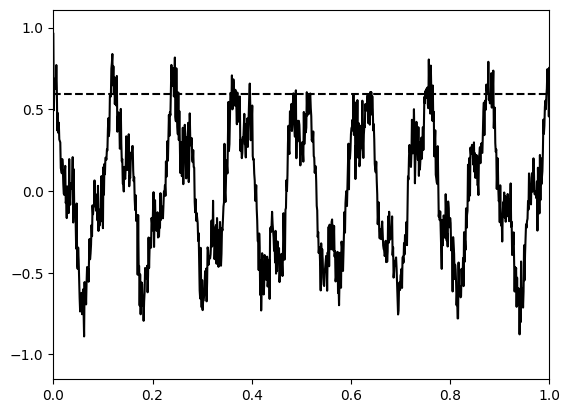

In [ ]:
# Your code goes here



::::{dropdown} Solution

:::{code-cell} python

threshold = np.mean(signal) + 1*np.std(signal)

# finding periods above the threshold
idx = np.where(signal>threshold)[0]

# looking for indices that are non consecutives 
transition = np.where(np.diff(idx)>1)[0]

# defining the onset and offset of threshold "activation"
start = np.concatenate([[idx[0]], idx[transition+1]])
end = np.concat([idx[transition], [idx[-1]]])
duration = end-start + 1

# estimating the sampling rate from the time vector
srate = int(1/np.diff(time)[0])

# fixing edges
start = start[duration>=0.01*srate]
end = end[duration>=0.01*srate]

# plotting
plt.plot(time, signal,'k')
plt.plot([time[0], time[-1]], threshold*np.ones(2),'--k')

for i in range(len(start)):
  plt.plot(time[start[i]:end[i]], signal[start[i]:end[i]],'r')

plt.xlim([0,1])
plt.show()
:::
::::

### Exercise 4:

As we saw above, the function `np.diff()` can be used to compute the difference between consecutive values in an array. So, for an array `arr`, `np.diff(arr)` is equivalent to: `arr[1:]-arr[0:]`. In a way, this quantity is related to the discrete derivative, and hence name diff, from differential.

```
print(np.diff([1, 3, 4, 10]))
[2 1 6]
```

As you might have learned in Calculus, the differential can be used to find local minima and local maxima in an array (inflexion points). Of course, because in a computer values are stored in a discrete way, an inflection point of an array `arr` can be found not by finding where `np.diff(arr) == 0`, but where `np.diff(arr)` changes from positive to negative.

Use the `np.diff` function to find all the peaks of the 8 Hz component found in the previous filtering exercise.

::::{note} Sign of a signal
Since to find transition points one only need to know the sign of the value in a specific position, one could simplify the derivative of the signal by only looking if a the values are positive or negative. How could you do that using array operations?

:::{tip}
:class: dropdown
You can do that by hand. But numpy also have an implementation for that. Check the function `np.sign()`.
:::
::::

In [ ]:
# Your code goes here



::::{dropdown} Solution

:::{code-cell} python

filtered = filter(signal, 5,10, 1/dt)

d_filtered = np.diff(filtered)
sign = np.sign(d_filtered)
sign_diff = np.diff(sign)

idx_peaks = np.where(sign_diff==-2) 

plt.plot(time, filtered,'k')
plt.plot(time[idx_peaks], filtered[idx_peaks], 'r.')
plt.xlim(0,1)
plt.show()
:::

::::{note}

The solution above is not complete. The code line: 

`idx_peaks = np.where(sign_diff==-2)`

Captures the case in which `sign` goes from 1 to -1 (i.e., which is a peak in the filtered signal). However, we are still missing the cases in which `sign` goes from 1, to 0, to -1. This is how it would happen in a continuous signal, and as much as it is not so probable to happen in a discrete signal, it is still possible. This case is a bit harder to capture because you need to diferentiate it from the other sequence: 1, 0, 1, which is an inflection point, but not a maxima. To help with that, we could use the `np.logical_and()` to look simultaneously at consecutive transitions.

:::{code-cell} python
:tags: [skip-execution]
:linenos:
:emphasize-lines: 9,13-14
filtered = filter(signal, 5,10, 1/dt)

d_filtered = np.diff(filtered)
sign = np.sign(d_filtered)
sign_diff = np.diff(sign)

idx_peaks = np.where(sign_diff==-2) 

idx_rare_peaks = np.where(np.logical_and(sign_diff[0:-1]==-1, sign_diff[1:]==-1))

plt.plot(time, filtered,'k')
plt.plot(time[idx_peaks], filtered[idx_peaks], 'r.')
if len(idx_rare_peaks)>0:
    plt.plot(time[idx_rare_peaks], filtered[idx_rare_peaks], 'r.')
plt.xlim(0,1)
plt.show()

::::